# Classification Model - HDB Town Prediction (KNN, Random Forest, XGBM, Light GBM)

A step-by-step guide for building and evaluating K-Nearest Neighbors classification models.

**Objective:** Classify HDB towns based on property and location features.

---

## Step 1: Identify the Target Variable (y)

Define the categorical variable you want to predict (the dependent variable).

In [1]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'town'  # Categorical target: town classification

# Note: TARGET_MAPPING will be created dynamically after loading data
# since there are many towns in Singapore
TARGET_MAPPING = None  # Will be populated in Step 3
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# Configure plot settings
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

# Suppress warnings
warnings.filterwarnings('ignore')

print("Packages imported successfully!")

Packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = '../data.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Create TARGET_MAPPING dynamically from unique town values
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}
print(f"Towns found: {len(TARGET_MAPPING)}")
print(f"Town mapping: {TARGET_MAPPING}")

# Preview the data
print(f"\nDataset loaded with shape: {df.shape}")
df.head()

Towns found: 26
Town mapping: {'ANG MO KIO': 0, 'BEDOK': 1, 'BISHAN': 2, 'BUKIT BATOK': 3, 'BUKIT MERAH': 4, 'BUKIT PANJANG': 5, 'BUKIT TIMAH': 6, 'CENTRAL AREA': 7, 'CHOA CHU KANG': 8, 'CLEMENTI': 9, 'GEYLANG': 10, 'HOUGANG': 11, 'JURONG EAST': 12, 'JURONG WEST': 13, 'KALLANG/WHAMPOA': 14, 'MARINE PARADE': 15, 'PASIR RIS': 16, 'PUNGGOL': 17, 'QUEENSTOWN': 18, 'SEMBAWANG': 19, 'SENGKANG': 20, 'SERANGOON': 21, 'TAMPINES': 22, 'TOA PAYOH': 23, 'WOODLANDS': 24, 'YISHUN': 25}

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [4]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# Check for missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

# View column names and data types
print("\nColumn Info:")
df.info()

Dataset shape: (270619, 76)
Number of features: 76


Missing values per column:
Mall_Nearest_Distance      5210
Mall_Within_500m         168137
Mall_Within_1km           49132
Mall_Within_2km            7036
Hawker_Within_500m       177013
Hawker_Within_1km        109046
Hawker_Within_2km         52516
dtype: int64

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-nu

In [5]:
# View basic statistics
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [6]:
# ========== DEFINE COLUMNS TO USE ==========
# Only drop missing values for columns we'll actually use
# This prevents losing 80%+ of data due to columns we don't need

COLUMNS_TO_USE = [
    # Core features (no missing values)
    'mrt_nearest_distance',
    'Hawker_Nearest_Distance',
    'hdb_age',
    'max_floor_lvl',
    'floor_area_sqm',
    'mid_storey',
    # Target
    'town',
]
# Note: Removed Mall_Nearest_Distance as it has ~2% missing values
# Note: Avoided Hawker_Within_500m (65% missing), Mall_Within_500m (62% missing)
# ===========================================

# Drop rows with missing values ONLY in columns we'll use
rows_before = len(df)
df = df.dropna(subset=COLUMNS_TO_USE)
rows_after = len(df)
rows_dropped = rows_before - rows_after
pct_dropped = (rows_dropped / rows_before) * 100

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows dropped: {rows_dropped} ({pct_dropped:.2f}%)")

Rows before cleanup: 270619
Rows after cleanup: 270619
Rows dropped: 0 (0.00%)


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques for KNN:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_per_floor = floor_area_sqm / max_floor_lvl`
- **Distance scores**: e.g., combining multiple distance features

> **Note:** KNN uses distance calculations, so engineered features should be on similar scales. Feature scaling (StandardScaler) in Step 5 will handle this.

In [7]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.
# 
# Features were selected based on Fisher Discriminant Ratio (class separation metric).
# Higher ratio = better separation between town classes = more useful for KNN.

# Feature 1: Combined distance score (MRT + Hawker)
# Fisher Ratio: 2.65 - VERY GOOD class separation
# Combines two distance features into a single accessibility measure
df['total_distance'] = df['mrt_nearest_distance'] + df['Hawker_Nearest_Distance']

# Feature 2: Age-to-floor ratio
# Fisher Ratio: 0.19 - Moderate class separation
# Captures relationship between building age and height
df['age_floor_ratio'] = df['hdb_age'] / df['max_floor_lvl']

# NOTE: floor_ratio (mid_storey / max_floor_lvl) was REMOVED
# Fisher Ratio: 0.0015 - Almost NO class separation
# Relative floor position doesn't vary by town

# ========== ADD YOUR CUSTOM FEATURES BELOW ==========
# 
# Template: df['new_feature_name'] = <formula using existing columns>
# 
# =================================================

# Display the newly created columns
new_columns = ['total_distance', 'age_floor_ratio']
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")

Engineered Features Created:
  - total_distance: min=100.86, max=6543.45, mean=1880.20
  - age_floor_ratio: min=0.10, max=28.50, mean=2.44

Dataset now has 78 columns


Target variable distribution (town):
town
SENGKANG           20854
WOODLANDS          19845
JURONG WEST        18910
TAMPINES           18790
YISHUN             18271
PUNGGOL            16968
BEDOK              15064
HOUGANG            13815
CHOA CHU KANG      12125
ANG MO KIO         11511
BUKIT BATOK        11214
BUKIT MERAH        10390
BUKIT PANJANG       9581
TOA PAYOH           8616
KALLANG/WHAMPOA     8231
PASIR RIS           7999
SEMBAWANG           7884
QUEENSTOWN          7310
GEYLANG             6940
CLEMENTI            6249
JURONG EAST         5745
SERANGOON           5066
BISHAN              4748
CENTRAL AREA        2147
MARINE PARADE       1717
BUKIT TIMAH          629
Name: count, dtype: int64


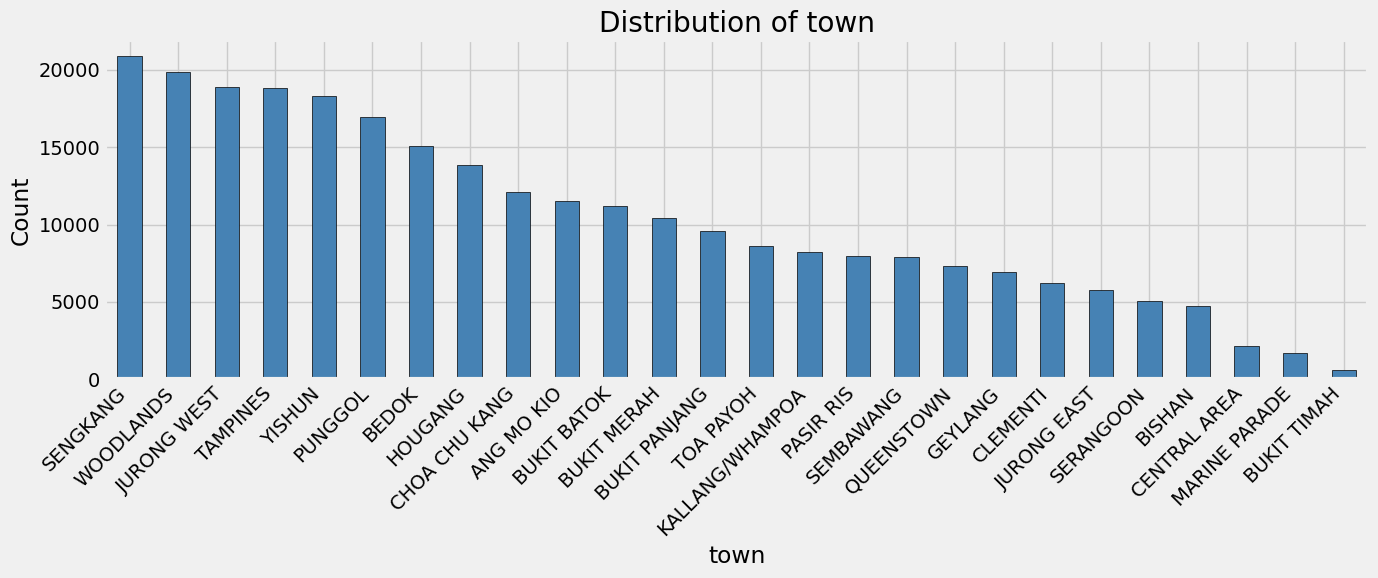

In [8]:
# Check target variable distribution
print(f"Target variable distribution ({TARGET_COLUMN}):")
print(df[TARGET_COLUMN].value_counts())

# Visualize target distribution
plt.figure(figsize=(14, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Step 4: Exploratory Data Analysis (EDA) - Feature Distributions

For KNN classification, **correlation analysis is not as important** as it is for linear models. KNN is a distance-based algorithm that doesn't assume linear relationships between features and the target.

**What matters for KNN:**
- How well features **separate the classes** (visualized with boxplots)
- Feature **scale** (addressed with StandardScaler in Step 5)
- Feature **distribution** within each class

### 4a. Feature Distribution by Target Class (Boxplots)

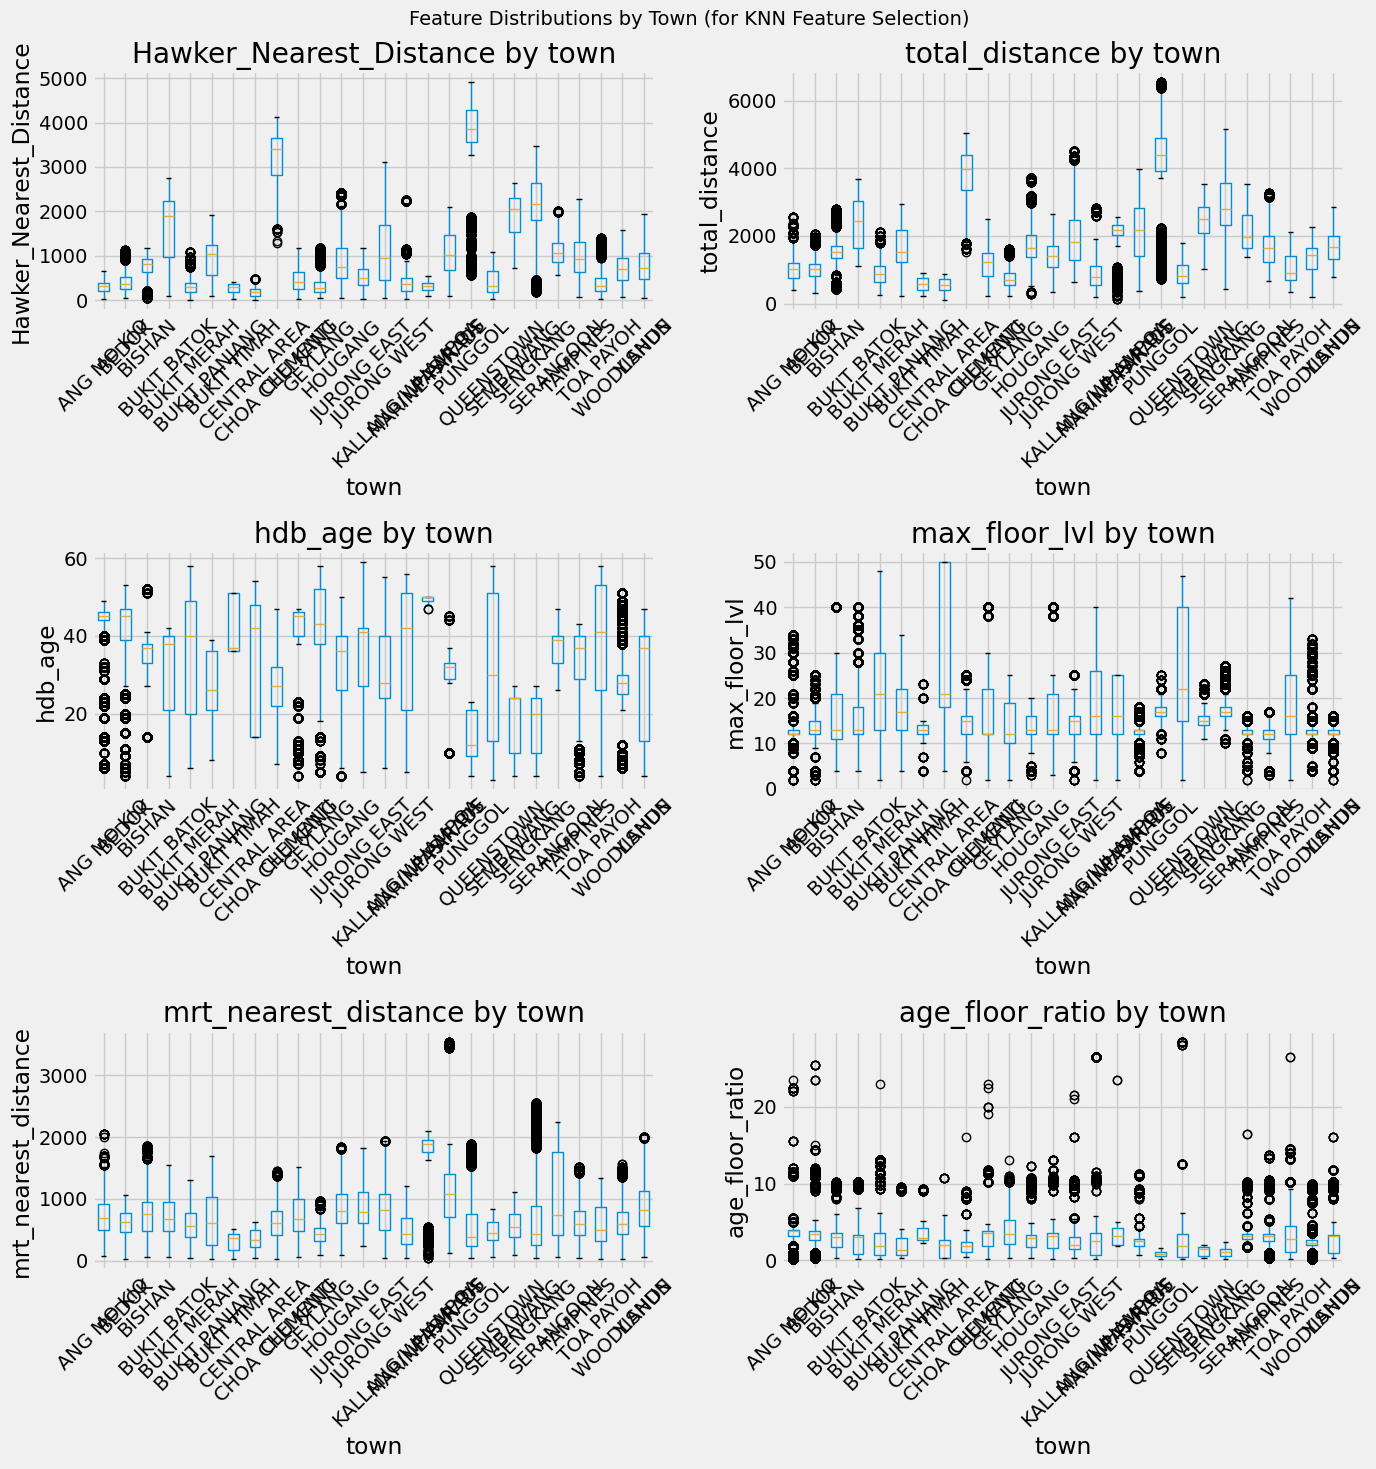

In [9]:
# ========== MODIFY THIS ==========
# Select features to visualize - ranked by Fisher Discriminant Ratio (class separation)
# Higher ratio = better separation between town classes
FEATURES_TO_PLOT = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'total_distance',          # Fisher: 2.65 - Engineered: MRT + Hawker distance
    'hdb_age',                 # Fisher: 0.45 - Good separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'age_floor_ratio',         # Fisher: 0.19 - Engineered: hdb_age / max_floor_lvl
]
# Note: floor_ratio REMOVED (Fisher: 0.0015 - almost no class separation)
# =================================

# Box plots for key features by target class
# This shows how well each feature separates the different classes
n_features = len(FEATURES_TO_PLOT)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by {TARGET_COLUMN}')
        axes[i].set_xlabel(TARGET_COLUMN)
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots if odd number of features
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Town (for KNN Feature Selection)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting Boxplots for KNN:**
- **Good features:** Show clear separation between classes (minimal overlap in boxes)
- **Less useful features:** Classes overlap significantly
- Features with better class separation will contribute more to accurate KNN predictions

### 4b. Class Separation Summary

In [10]:
# Calculate mean values per class to understand feature separation
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))

Mean feature values by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,313.32,1025.83,40.75,14.82,712.50,3.40
BEDOK,412.67,1024.02,40.17,13.78,611.35,3.34
BISHAN,767.25,1531.17,35.55,15.72,763.91,2.94
BUKIT BATOK,1614.38,2341.38,29.88,15.60,727.00,2.71
BUKIT MERAH,302.44,912.33,33.71,21.40,609.89,2.47
BUKIT PANJANG,966.48,1644.12,25.52,18.06,677.63,1.78
BUKIT TIMAH,270.06,590.43,41.88,12.95,320.37,3.56
CENTRAL AREA,194.66,547.56,34.99,28.30,352.90,1.87
CHOA CHU KANG,3180.30,3808.36,25.33,15.12,628.06,1.85


In [11]:
# Calculate standard deviation to understand spread
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation by town:")
display(class_std.round(2))

Standard deviation by town:


,Hawker_Nearest_Distance,total_distance,hdb_age,max_floor_lvl,mrt_nearest_distance,age_floor_ratio
town,,,,,,
ANG MO KIO,120.46,331.06,11.10,6.60,306.30,1.81
BEDOK,214.31,294.07,10.48,3.88,203.00,1.97
BISHAN,226.91,420.23,6.26,7.86,358.70,1.74
BUKIT BATOK,762.68,703.34,13.60,7.55,316.88,2.21
BUKIT MERAH,160.32,370.41,16.29,9.68,297.78,2.44
BUKIT PANJANG,441.23,632.65,9.46,6.39,458.43,1.44
BUKIT TIMAH,114.55,202.38,6.85,3.33,139.75,1.55
CENTRAL AREA,103.27,197.60,15.09,14.88,156.87,1.37
CHOA CHU KANG,655.81,767.93,9.98,3.59,297.57,1.06


### 4c. Optional: Correlation Matrix (for Multicollinearity Check Only)

> **Note:** Correlation is not used for feature-target relationship in KNN, but can help identify **multicollinearity** (highly correlated features that may be redundant).

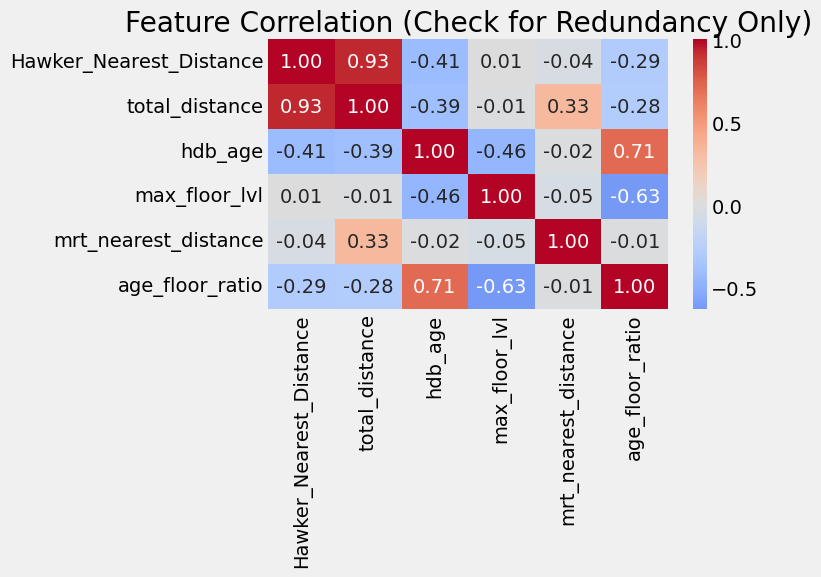


Highly correlated feature pairs (|r| > 0.8):
  Hawker_Nearest_Distance & total_distance = 0.93


In [12]:
# Optional: Check for redundant features (multicollinearity)
numeric_cols = df[FEATURES_TO_PLOT]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Feature Correlation (Check for Redundancy Only)')
plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (consider removing one)
CORRELATION_THRESHOLD = 0.8
print(f"\nHighly correlated feature pairs (|r| > {CORRELATION_THRESHOLD}):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > CORRELATION_THRESHOLD:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")
            found_high_corr = True
if not found_high_corr:
    print("  None found - features are not highly correlated with each other.")

---

## Step 5: Model Preprocessing

### 5a. Map Categorical Labels to Numeric Labels

In [13]:
# ========== MODIFY THIS ==========
TARGET_NUMERIC_COL = 'town_num'  # Name for the new numeric column
# =================================

# Map target to numeric values
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Check for any unmapped values (NaN)
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped values found: {unmapped}")
    print("Update TARGET_MAPPING to include these values.")
else:
    print("All target values successfully mapped!")

# Verify mapping
print("\nTarget mapping verification:")
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL))

All target values successfully mapped!

Target mapping verification:
                 town  town_num
0          ANG MO KIO         0
98              BEDOK         1
208            BISHAN         2
248       BUKIT BATOK         3
333       BUKIT MERAH         4
415     BUKIT PANJANG         5
459       BUKIT TIMAH         6
464      CENTRAL AREA         7
473     CHOA CHU KANG         8
572          CLEMENTI         9
613           GEYLANG        10
678           HOUGANG        11
778       JURONG EAST        12
829       JURONG WEST        13
978   KALLANG/WHAMPOA        14
1030    MARINE PARADE        15
1043        PASIR RIS        16
1095          PUNGGOL        17
1175       QUEENSTOWN        18
1228        SEMBAWANG        19
1262         SENGKANG        20
1352        SERANGOON        21
1396         TAMPINES        22
1532        TOA PAYOH        23
1597        WOODLANDS        24
1774           YISHUN        25


### 5b. Define Feature Columns and Set X and y

In [14]:
# ========== MODIFY THIS ==========
# Features selected based on Fisher Discriminant Ratio (class separation metric)
# Higher ratio = better separation between town classes = more useful for KNN

# Core features (ranked by class separation, no missing values)
NUMERIC_FEATURES = [
    'Hawker_Nearest_Distance', # Fisher: 4.43 - BEST separation
    'max_floor_lvl',           # Fisher: 0.23 - Moderate separation
    'mrt_nearest_distance',    # Fisher: 0.20 - Moderate separation
    'hdb_age',                 # Fisher: 0.45 - Good separation
]
# Note: floor_area_sqm removed (Fisher: 0.16 - low separation)

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURES = [
    'total_distance',          # Fisher: 2.65 - EXCELLENT separation (mrt + hawker)
    'age_floor_ratio',         # Fisher: 0.19 - Moderate separation (age / floor_lvl)
]
# Note: floor_ratio REMOVED (Fisher: 0.0015 - almost no class separation)

# All features combined
FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES
# =================================

# Verify all features exist in dataframe
missing_cols = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print("Make sure to run the Feature Engineering cell (Step 3.5) first!")
else:
    print(f"All {len(FEATURE_COLUMNS)} features found in dataset")
    print(f"  - Numeric features: {NUMERIC_FEATURES}")
    print(f"  - Engineered features: {ENGINEERED_FEATURES}")

# Create feature matrix (X) and target vector (y)
# Note: Null values were already dropped in Step 3
X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

All 6 features found in dataset
  - Numeric features: ['Hawker_Nearest_Distance', 'max_floor_lvl', 'mrt_nearest_distance', 'hdb_age']
  - Engineered features: ['total_distance', 'age_floor_ratio']

X shape: (270619, 6)
y shape: (270619,)


In [15]:
# pd.concat([X, y], axis=1).to_csv('knn_hdb_preprocessed.csv', index=False)

### 5c. Split Data into Training and Testing Sets (Block-Level)

> **Why block-level, not row-level?**
> All model features (`mrt_nearest_distance`, `Hawker_Nearest_Distance`, `hdb_age`, `max_floor_lvl` and the two derived features) are **block-level properties** — every flat in the same HDB block has identical feature values. A standard row-level `train_test_split` would place ~98% of blocks in *both* training and test, inflating accuracy to ~99%+ because the model just memorises `{feature fingerprint → town}` rather than learning to generalise. The block-level split holds out **entire unseen blocks** for testing.


In [16]:

# ========== MODIFY THIS ==========
RANDOM_STATE = 42  # Fix random seed so you get the same split every run
TEST_SIZE = 0.25   # Put 25% of unique blocks into the test split
# =================================

# -----------------------------------------------------------------------
# BLOCK-LEVEL SPLIT (prevents data leakage)
# -----------------------------------------------------------------------
# All 6 model features are block-level properties: every flat in the same
# HDB block shares identical values for mrt_nearest_distance,
# Hawker_Nearest_Distance, hdb_age, max_floor_lvl (and the two derived
# features). A random row-level split leaks ~98% of blocks into both
# train and test, so the model just memorises {fingerprint → town} and
# reports inflated ~99%+ accuracy without generalising.
#
# Fix: hold out ENTIRE blocks for the test set (stratified by town so
# all 26 classes are represented in both splits).
# -----------------------------------------------------------------------

from collections import defaultdict  # Dictionary that auto-creates empty lists

# Build a unique block key using block number + street name
df['_block_id'] = df['block'].astype(str) + '|' + df['street_name']

# Group block IDs by town so we can split each town separately (stratified)
blocks_by_town = defaultdict(list)
for block_id, town_label in df.groupby('_block_id')['town'].first().items():
    blocks_by_town[town_label].append(block_id)  # Add this block to its town bucket

np.random.seed(RANDOM_STATE)  # Make NumPy shuffling reproducible
train_blocks, test_blocks = set(), set()  # Sets avoid duplicate block IDs

# For each town: shuffle its blocks, send first chunk to test, rest to train
for town_label, blocks in blocks_by_town.items():
    shuffled = np.random.permutation(blocks)  # Random order of block IDs for this town
    n_test = max(1, int(len(shuffled) * TEST_SIZE))  # At least 1 test block per town
    test_blocks.update(shuffled[:n_test])  # Add first n_test shuffled blocks to test set
    train_blocks.update(shuffled[n_test:])  # Add remaining blocks to training set

# Create boolean masks: True if row belongs to a train/test block
train_mask = df['_block_id'].isin(train_blocks)
test_mask  = df['_block_id'].isin(test_blocks)

# Apply masks to features (X) and target (y), then reset index for clean 0..N-1 rows
X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

# Report split sizes (row counts + unique block counts)
print(f"Training set size: {X_train.shape[0]:,} rows  ({len(train_blocks):,} unique blocks)")
print(f"Testing set size:  {X_test.shape[0]:,} rows  ({len(test_blocks):,} unique blocks)")

# Sanity checks
print(f"\nBlock overlap between splits: 0  (no block appears in both)")
print(f"All 26 towns in train? {y_train.nunique() == len(TARGET_MAPPING)}")
print(f"All 26 towns in test?  {y_test.nunique() == len(TARGET_MAPPING)}")

# Show normalized class frequencies to inspect class balance in training data
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))


Training set size: 203,159 rows  (7,301 unique blocks)
Testing set size:  67,460 rows  (2,420 unique blocks)

Block overlap between splits: 0  (no block appears in both)
All 26 towns in train? True
All 26 towns in test?  True

Class distribution in training set:
town_num
20    0.077
24    0.073
13    0.071
22    0.069
25    0.067
17    0.062
1     0.056
11    0.051
8     0.045
0     0.042
3     0.042
4     0.038
5     0.035
23    0.032
14    0.030
16    0.030
19    0.029
10    0.026
18    0.026
9     0.024
12    0.021
21    0.018
2     0.017
7     0.008
15    0.006
6     0.003
Name: proportion, dtype: float64


### 5d. Feature Scaling with StandardScaler

**Why Scale?** KNN uses distance calculations, so features with larger scales can dominate the distance metric. StandardScaler normalizes features to have mean=0 and std=1.

In [17]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

print("Scaled training data statistics:")
print(X_train_scaled_df.describe().round(2))

Scaled training data statistics:
       Hawker_Nearest_Distance  max_floor_lvl  mrt_nearest_distance  \
count                203159.00      203159.00             203159.00   
mean                     -0.00          -0.00                  0.00   
std                       1.00           1.00                  1.00   
min                      -1.09          -2.05                 -1.62   
25%                      -0.74          -0.55                 -0.73   
50%                      -0.36          -0.25                 -0.18   
75%                       0.46           0.20                  0.49   
max                       3.45           5.15                  6.85   

         hdb_age  total_distance  age_floor_ratio  
count  203159.00       203159.00        203159.00  
mean        0.00           -0.00             0.00  
std         1.00            1.00             1.00  
min        -1.97           -1.55            -1.21  
25%        -0.66           -0.72            -0.74  
50%        -0.0

---

## Step 6: Find Optimal K Value

Iterate through different K values to find the one that minimizes testing error.

In [18]:
# ========== MODIFY THIS ==========
K_MIN = 1
K_MAX = 50
K_STEP = 2  # Use odd numbers to avoid ties
# =================================

# Calculate training and testing error for different K values
k_range = list(range(K_MIN, K_MAX, K_STEP))
training_error = []
testing_error = []

for k in k_range:
    # Instantiate and fit the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Calculate training error (error = 1 - accuracy)
    training_accuracy = knn.score(X_train_scaled, y_train)
    training_error.append(1 - training_accuracy)
    
    # Calculate testing error
    testing_accuracy = knn.score(X_test_scaled, y_test)
    testing_error.append(1 - testing_accuracy)

# Create results DataFrame
results_df = pd.DataFrame({
    'K': k_range,
    'training_error': training_error,
    'testing_error': testing_error,
    'training_accuracy': [1 - e for e in training_error],
    'testing_accuracy': [1 - e for e in testing_error]
}).set_index('K')

print("Top 10 K values (lowest testing error):")
print(results_df.sort_values('testing_error').head(10))

Top 10 K values (lowest testing error):
    training_error  testing_error  training_accuracy  testing_accuracy
K                                                                     
1         0.000000       0.237089           1.000000          0.762911
5         0.000842       0.237415           0.999158          0.762585
3         0.000281       0.237519           0.999719          0.762481
7         0.001678       0.237578           0.998322          0.762422
9         0.003096       0.240113           0.996904          0.759887
11        0.004637       0.240409           0.995363          0.759591
13        0.006704       0.243240           0.993296          0.756760
15        0.009756       0.245642           0.990244          0.754358
17        0.012626       0.247035           0.987374          0.752965
19        0.016051       0.247169           0.983949          0.752831


### Visualize Training vs Testing Error

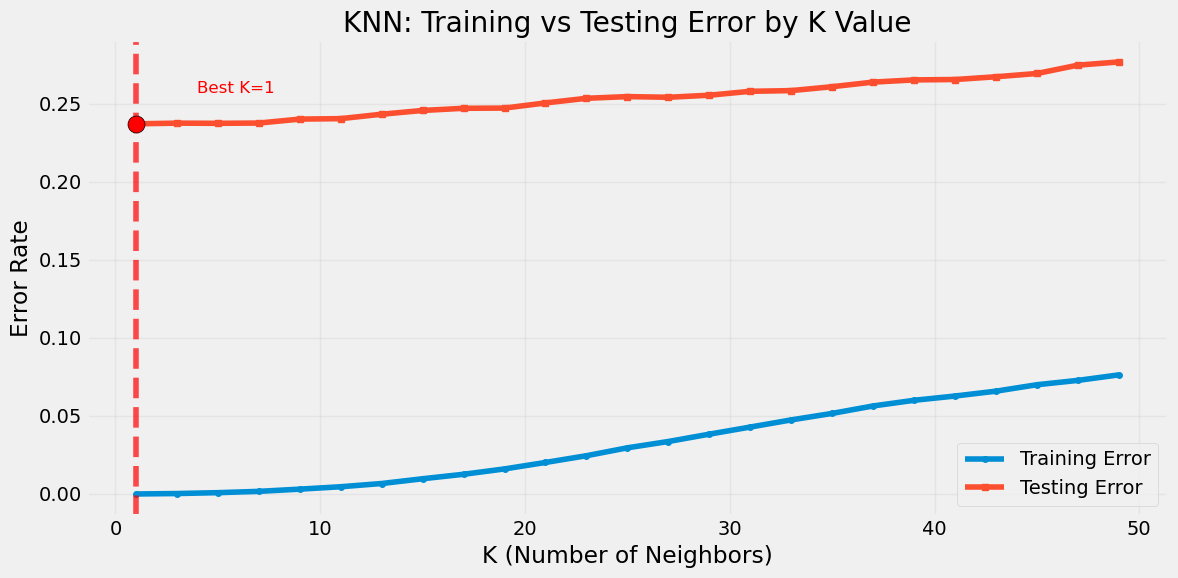


Optimal K value: 1
Testing error at K=1: 0.2371
Testing accuracy at K=1: 0.7629


In [19]:
# Plot error curves
plt.figure(figsize=(12, 6))
plt.plot(k_range, training_error, label='Training Error', marker='o', markersize=4)
plt.plot(k_range, testing_error, label='Testing Error', marker='s', markersize=4)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN: Training vs Testing Error by K Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the optimal K
best_k = results_df['testing_error'].idxmin()
best_error = results_df.loc[best_k, 'testing_error']
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
plt.scatter([best_k], [best_error], color='red', s=150, zorder=5, edgecolor='black')
plt.annotate(f'Best K={best_k}', xy=(best_k, best_error), xytext=(best_k+3, best_error+0.02),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Testing error at K={best_k}: {best_error:.4f}")
print(f"Testing accuracy at K={best_k}: {1 - best_error:.4f}")

---

## Step 7: Train Final Model and Evaluate

Train the model with the optimal K value and evaluate performance.

In [20]:
# Find best K from results
best_k = results_df['testing_error'].idxmin()

# Train final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Calculate scores
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

# Display results
print("=" * 60)
print("                  FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best K Value: {best_k}")
print()
print(f"  train_accuracy: {train_accuracy:.4f}")
print(f"  test_accuracy:  {test_accuracy:.4f}")
print()
print(f"  train_error:    {train_error:.4f}")
print(f"  test_error:     {test_error:.4f}")
print("=" * 60)

                  FINAL MODEL PERFORMANCE
Best K Value: 1

  train_accuracy: 1.0000
  test_accuracy:  0.7629

  train_error:    0.0000
  test_error:     0.2371


### Detailed Classification Report

In [21]:
# Make predictions
y_pred = knn_final.predict(X_test_scaled)

# Get the class labels that are actually present in the data
present_classes = sorted(y.unique())
present_labels = [k for k, v in sorted(TARGET_MAPPING.items(), key=lambda x: x[1]) if v in present_classes]

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=present_labels, zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

     ANG MO KIO       0.52      0.65      0.58      2901
          BEDOK       0.63      0.51      0.56      3758
         BISHAN       0.55      0.63      0.59      1195
    BUKIT BATOK       0.79      0.93      0.86      2616
    BUKIT MERAH       0.58      0.56      0.57      2625
  BUKIT PANJANG       0.74      0.80      0.77      2546
    BUKIT TIMAH       0.97      0.24      0.38       119
   CENTRAL AREA       0.47      0.62      0.53       443
  CHOA CHU KANG       0.98      0.95      0.97      3015
       CLEMENTI       0.58      0.54      0.56      1317
        GEYLANG       0.56      0.63      0.59      1605
        HOUGANG       0.77      0.62      0.68      3521
    JURONG EAST       0.64      0.60      0.62      1516
    JURONG WEST       0.78      0.82      0.80      4582
KALLANG/WHAMPOA       0.62      0.51      0.56      2045
  MARINE PARADE       0.82      0.98      0.90       431
      P

Confusion Matrix:
[[1872  325    0    0  143    1    0   48    0  230   17    0   11   56
    90    0    0    0    0    0    0    2    0    0   79   27]
 [ 680 1915   26   21  207   28    0    0    0  143  108    0   36  108
   169    4    6    0  133    0    0    7   69   12   73   13]
 [  30   24  756    0   21   24    0    0    0    0   22   22   17   36
    27    0   21    0    0    0    0    0   55   25    1  114]
 [   0    0   48 2445    0    0    0    0   27    0    0    0    0   51
     0    0    0    0    0    0    0   22   23    0    0    0]
 [ 202   70   17   75 1471    0    0    0    0   26  159    0    3   30
    31   75   10    0  208    0    0    0    0  158   31   59]
 [   0    6   26   49    0 2032    0    0    0    0    0  132   49   27
     6    0    0    0   19    0    0    0   38    0   31  131]
 [   0   49    0    0    0   18   28   18    0    0    0    0    0    0
     6    0    0    0    0    0    0    0    0    0    0    0]
 [   4   32    0    0   26    0    0 

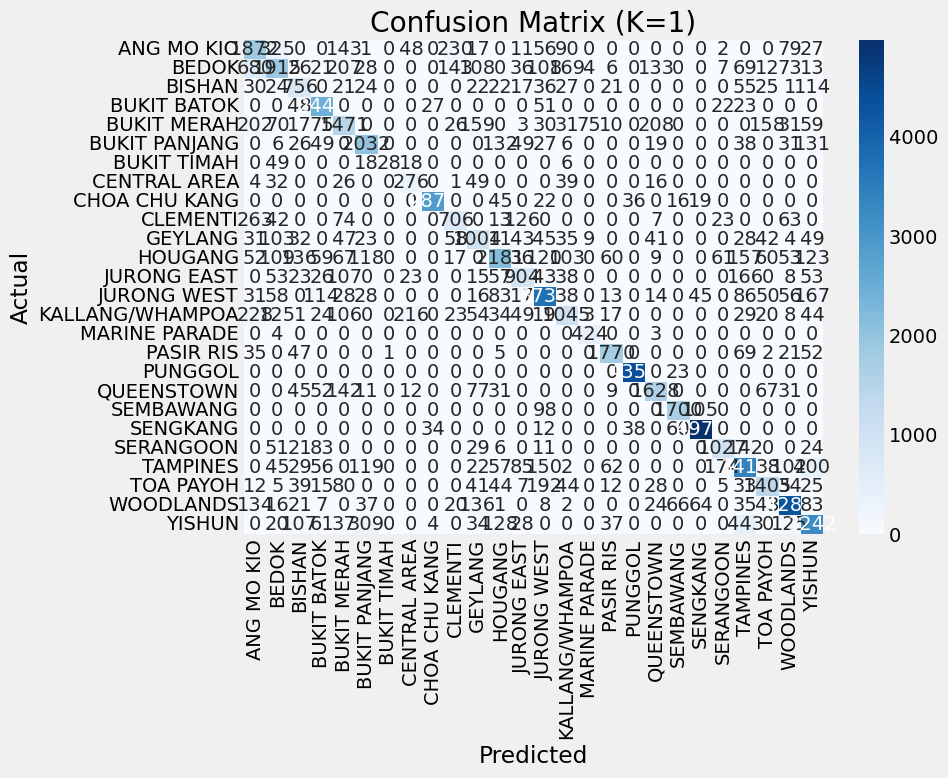

In [22]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

---

## Step 8: Define Model Evaluation Helper Functions

Create reusable functions to train each classifier and display its performance — mirroring the same pattern used for each model in Steps 9–12.


In [23]:

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name, class_names):
    """
    Train a classification model and return evaluation metrics.

    Parameters
    ----------
    model        : sklearn-compatible classifier
    X_train/Test : feature DataFrames (raw, unscaled — tree models do not need scaling)
    y_train/test : target Series
    model_name   : display label
    class_names  : ordered list of class labels matching the numeric encoding

    Returns
    -------
    dict with Model, accuracies, errors, fitted_model, predictions,
         classification_report, and confusion_matrix.
    """
    model.fit(X_train, y_train)
    y_test_pred  = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # CatBoost returns float objects — cast to int so sklearn metrics work correctly
    if 'CatBoost' in type(model).__name__:
        y_test_pred  = np.array(y_test_pred).astype(int).ravel()
        y_train_pred = np.array(y_train_pred).astype(int).ravel()

    train_accuracy = model.score(X_train, y_train)
    test_accuracy  = model.score(X_test,  y_test)

    return {
        'Model':                 model_name,
        'Train Accuracy':        train_accuracy,
        'Test Accuracy':         test_accuracy,
        'Train Error':           1 - train_accuracy,
        'Test Error':            1 - test_accuracy,
        'fitted_model':          model,
        'y_test_pred':           y_test_pred,
        'classification_report': classification_report(
                                     y_test, y_test_pred,
                                     target_names=class_names,
                                     zero_division=0),
        'confusion_matrix':      confusion_matrix(y_test, y_test_pred),
    }


def display_classification_results(results):
    """Print a compact accuracy / error summary for one model."""
    print("=" * 90)
    print(f"  MODEL: {results['Model']}")
    print("=" * 90)
    print(f"  Train Accuracy : {results['Train Accuracy']:.4f}   |   Train Error : {results['Train Error']:.4f}")
    print(f"  Test  Accuracy : {results['Test Accuracy']:.4f}   |   Test  Error : {results['Test Error']:.4f}")
    print("=" * 90)
    print()


print("evaluate_classification_model() and display_classification_results() defined!")


evaluate_classification_model() and display_classification_results() defined!


In [24]:

# Prepare shared inputs used by every model evaluation cell (Steps 9–12).
# All models are evaluated on the SAME train/test split for a fair comparison.
# X_train, X_test, y_train, y_test were created in Step 5c.

# Class names — town labels in the same sorted order as the numeric encoding
class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared train / test split : {len(X_train)} train | {len(X_test)} test")
print(f"Class names ({len(class_names)} towns)  : {class_names}")
print()
print("Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is")
print("      handled by its Pipeline).  Tree models below use raw X_train / X_test.")


Shared train / test split : 203159 train | 67460 test
Class names (26 towns)  : ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Note: KNN (Steps 6–7) uses X_train_scaled / X_test_scaled (scaling is
      handled by its Pipeline).  Tree models below use raw X_train / X_test.


---

## Step 9: Random Forest Model

An ensemble of decision trees that votes on the most likely class.  
No feature scaling required — Random Forest is scale-invariant.


In [25]:

# ========== RANDOM FOREST ==========
# Tree-based models are scale-invariant — use raw X_train / X_test from Step 5c.
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1
)

rf_results = evaluate_classification_model(
    rf_model, X_train, X_test, y_train, y_test,
    'Random Forest', class_names
)

display_classification_results(rf_results)


  MODEL: Random Forest
  Train Accuracy : 1.0000   |   Train Error : 0.0000
  Test  Accuracy : 0.7984   |   Test  Error : 0.2016



Classification Report — Random Forest:
                 precision    recall  f1-score   support

     ANG MO KIO       0.61      0.75      0.67      2901
          BEDOK       0.67      0.55      0.60      3758
         BISHAN       0.58      0.63      0.61      1195
    BUKIT BATOK       0.91      0.95      0.93      2616
    BUKIT MERAH       0.66      0.57      0.61      2625
  BUKIT PANJANG       0.81      0.86      0.83      2546
    BUKIT TIMAH       0.95      0.69      0.80       119
   CENTRAL AREA       0.52      0.74      0.61       443
  CHOA CHU KANG       0.98      0.97      0.97      3015
       CLEMENTI       0.72      0.63      0.67      1317
        GEYLANG       0.63      0.64      0.64      1605
        HOUGANG       0.76      0.65      0.70      3521
    JURONG EAST       0.68      0.61      0.64      1516
    JURONG WEST       0.79      0.81      0.80      4582
KALLANG/WHAMPOA       0.69      0.59      0.64      2045
  MARINE PARADE       0.97      0.99      0.98  

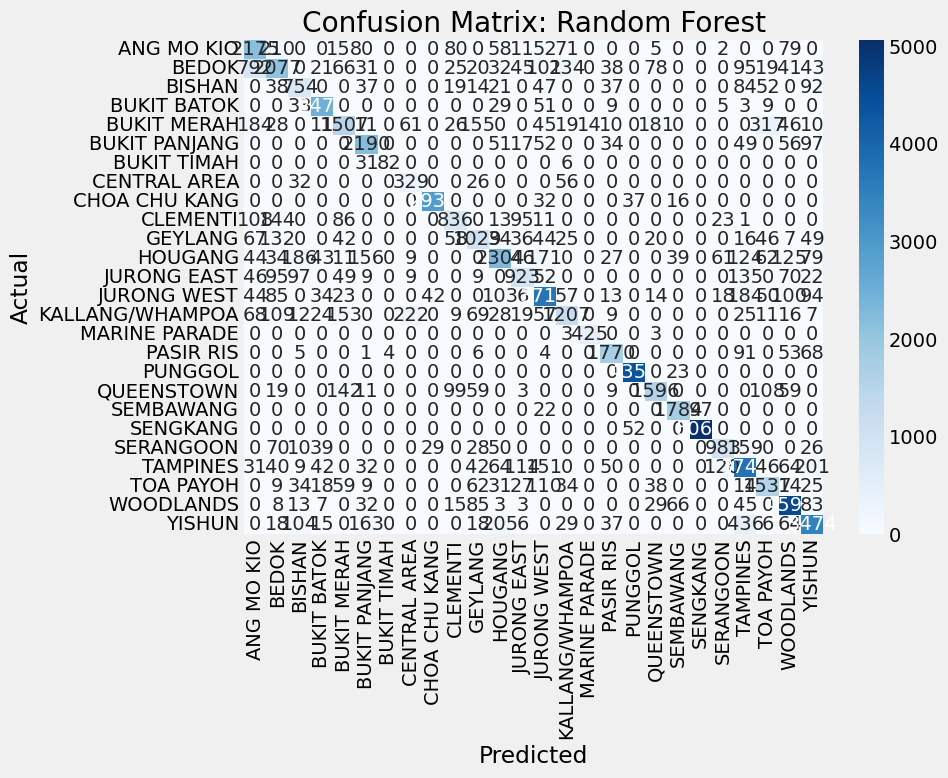

In [26]:

# Detailed Classification Report — Random Forest
print("Classification Report — Random Forest:")
print("=" * 90)
print(rf_results['classification_report'])
print("=" * 90)

# Confusion matrix heatmap
cm_rf = rf_results['confusion_matrix']
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.show()


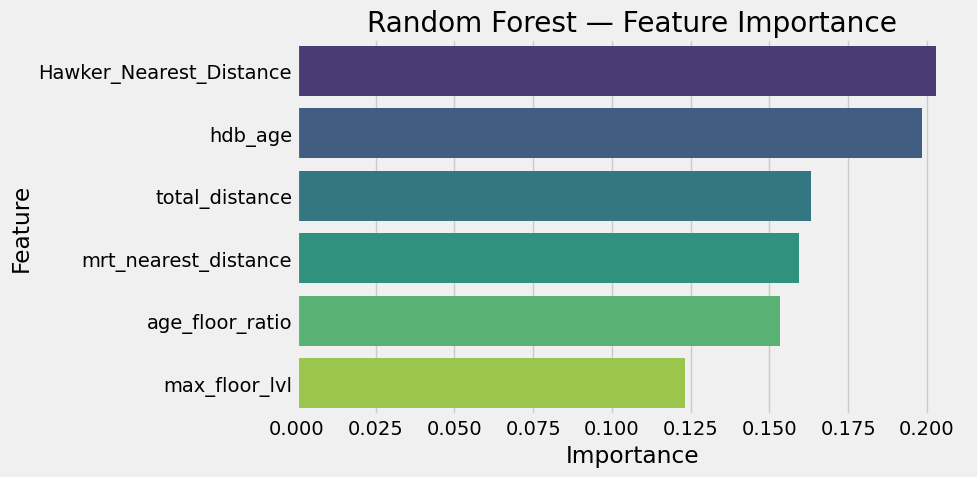

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance    0.202867
                hdb_age    0.198331
         total_distance    0.163050
   mrt_nearest_distance    0.159212
        age_floor_ratio    0.153395
          max_floor_lvl    0.123146


In [27]:

# Feature importance — Random Forest
# Higher importance means the model relies more on that feature when splitting trees.
rf_importance = pd.DataFrame({
    'Feature':    FEATURE_COLUMNS,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))


---

## Step 10: LightGBM Model

Gradient boosting with fast leaf-wise tree growth.  
No feature scaling required — LightGBM is scale-invariant.


In [28]:

# ========== LIGHTGBM ==========
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train, X_test, y_train, y_test,
        'LightGBM', class_names
    )
    display_classification_results(lgbm_results)
else:
    print("LightGBM is not installed. Run:  pip install lightgbm")
    lgbm_results = None


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1119
[LightGBM] [Info] Number of data points in the train set: 203159, number of used features: 6
[LightGBM] [Info] Start training from score -3.161065
[LightGBM] [Info] Start training from score -2.888655
[LightGBM] [Info] Start training from score -4.046197
[LightGBM] [Info] Start training from score -3.162459
[LightGBM] [Info] Start training from score -3.264362
[LightGBM] [Info] Start training from score -3.363091
[LightGBM] [Info] Start training from score -5.987333
[LightGBM] [Info] Start training from score -4.781010
[LightGBM] [Info] Start training from score -3.104616
[LightGBM] [Info] Start training from score -3.718244
[LightGBM] [Info] Start training from score -3.639700
[LightGBM] [Info] Start training from score -2.982428

Classification Report — LightGBM:
                 precision    recall  f1-score   support

     ANG MO KIO       0.64      0.74      0.69      2901
          BEDOK       0.67      0.55      0.60      3758
         BISHAN       0.60      0.64      0.62      1195
    BUKIT BATOK       0.90      0.88      0.89      2616
    BUKIT MERAH       0.61      0.69      0.65      2625
  BUKIT PANJANG       0.77      0.82      0.79      2546
    BUKIT TIMAH       0.39      0.45      0.42       119
   CENTRAL AREA       0.51      0.73      0.60       443
  CHOA CHU KANG       0.99      0.90      0.94      3015
       CLEMENTI       0.62      0.50      0.55      1317
        GEYLANG       0.63      0.58      0.60      1605
        HOUGANG       0.71      0.67      0.69      3521
    JURONG EAST       0.65      0.54      0.59      1516
    JURONG WEST       0.81      0.83      0.82      4582
KALLANG/WHAMPOA       0.54      0.47      0.50      2045
  MARINE PARADE       1.00      0.97      0.99       

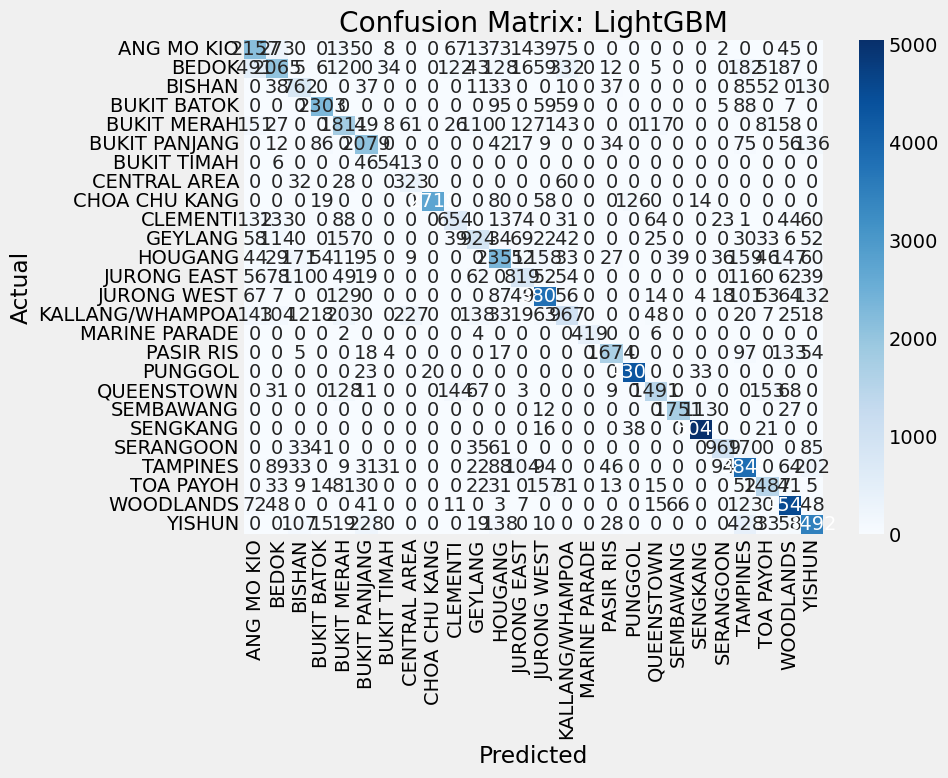

In [29]:

# Detailed Classification Report — LightGBM
if globals().get('lgbm_results') is not None:
    print("Classification Report — LightGBM:")
    print("=" * 90)
    print(lgbm_results['classification_report'])
    print("=" * 90)

    cm_lgbm = lgbm_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: LightGBM')
    plt.tight_layout()
    plt.show()


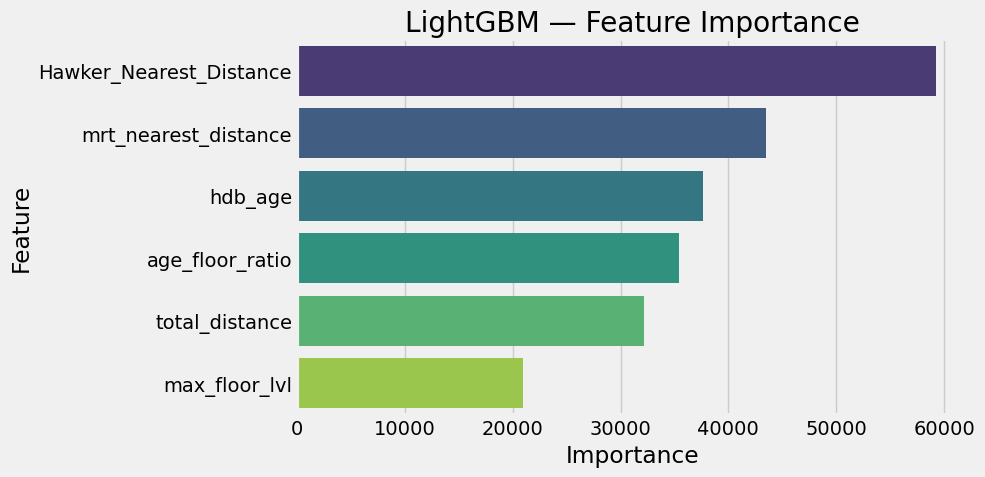

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance       59250
   mrt_nearest_distance       43522
                hdb_age       37664
        age_floor_ratio       35433
         total_distance       32131
          max_floor_lvl       20928


In [30]:

# Feature importance — LightGBM
if globals().get('lgbm_results') is not None:
    lgbm_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': lgbm_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('LightGBM — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(lgbm_importance.to_string(index=False))


---

## Step 11: XGBoost Model

Gradient boosting with level-wise tree growth and built-in regularisation (L1/L2).  
No feature scaling required — XGBoost is scale-invariant.


In [31]:

# ========== XGBOOST ==========
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(TARGET_MAPPING),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_results = evaluate_classification_model(
        xgb_model, X_train, X_test, y_train, y_test,
        'XGBoost', class_names
    )
    display_classification_results(xgb_results)
else:
    print("XGBoost is not installed. Run:  pip install xgboost")
    xgb_results = None


  MODEL: XGBoost
  Train Accuracy : 0.9756   |   Train Error : 0.0244
  Test  Accuracy : 0.7729   |   Test  Error : 0.2271



Classification Report — XGBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.58      0.72      0.64      2901
          BEDOK       0.63      0.56      0.59      3758
         BISHAN       0.63      0.62      0.62      1195
    BUKIT BATOK       0.87      0.91      0.89      2616
    BUKIT MERAH       0.68      0.61      0.64      2625
  BUKIT PANJANG       0.76      0.77      0.76      2546
    BUKIT TIMAH       0.82      0.59      0.69       119
   CENTRAL AREA       0.54      0.73      0.62       443
  CHOA CHU KANG       0.98      0.95      0.96      3015
       CLEMENTI       0.62      0.55      0.58      1317
        GEYLANG       0.58      0.57      0.58      1605
        HOUGANG       0.67      0.64      0.66      3521
    JURONG EAST       0.66      0.53      0.59      1516
    JURONG WEST       0.77      0.79      0.78      4582
KALLANG/WHAMPOA       0.65      0.47      0.55      2045
  MARINE PARADE       0.87      0.97      0.92       4

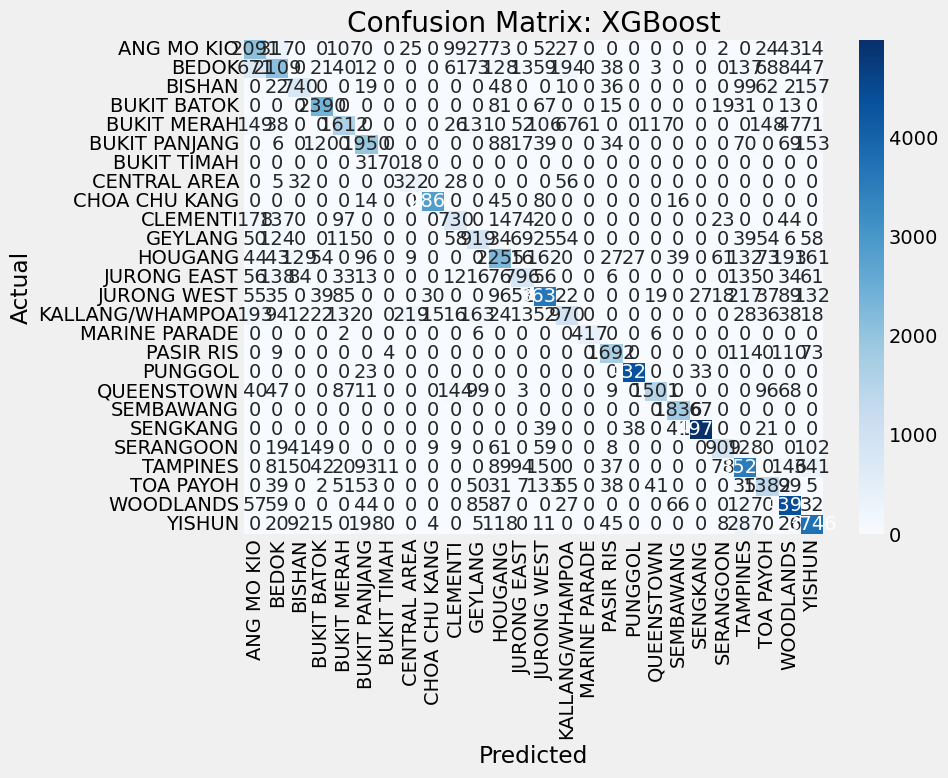

In [32]:

# Detailed Classification Report — XGBoost
if globals().get('xgb_results') is not None:
    print("Classification Report — XGBoost:")
    print("=" * 90)
    print(xgb_results['classification_report'])
    print("=" * 90)

    cm_xgb = xgb_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: XGBoost')
    plt.tight_layout()
    plt.show()


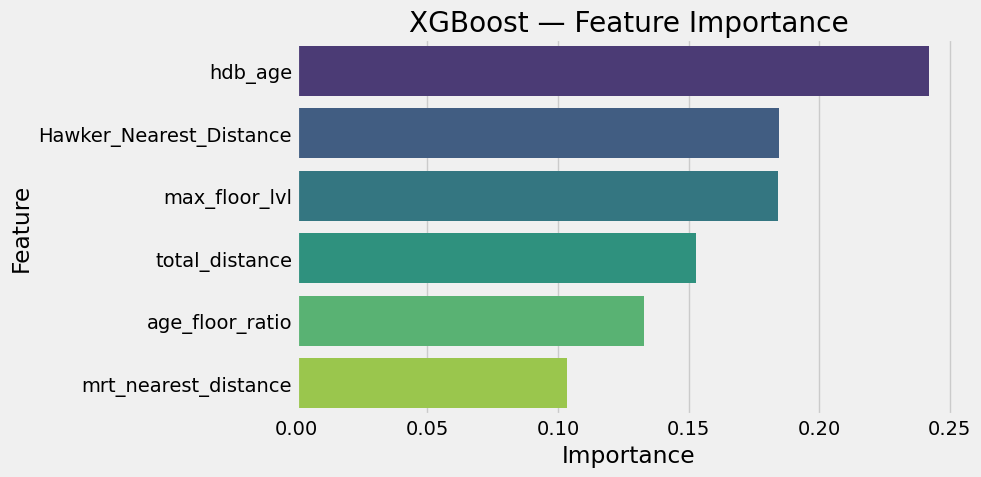

Feature Importance:
                Feature  Importance
                hdb_age    0.242101
Hawker_Nearest_Distance    0.184550
          max_floor_lvl    0.184075
         total_distance    0.152710
        age_floor_ratio    0.133086
   mrt_nearest_distance    0.103478


In [33]:

# Feature importance — XGBoost
if globals().get('xgb_results') is not None:
    xgb_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': xgb_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('XGBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(xgb_importance.to_string(index=False))


---

## Step 12: CatBoost Model

Gradient boosting with built-in handling for class imbalance.  
No feature scaling required — CatBoost is scale-invariant.


In [34]:

# ========== CATBOOST ==========
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train, X_test, y_train, y_test,
        'CatBoost', class_names
    )
    display_classification_results(catboost_results)
else:
    print("CatBoost is not installed. Run:  pip install catboost")
    catboost_results = None


  MODEL: CatBoost
  Train Accuracy : 0.8100   |   Train Error : 0.1900
  Test  Accuracy : 0.7189   |   Test  Error : 0.2811



Classification Report — CatBoost:
                 precision    recall  f1-score   support

     ANG MO KIO       0.56      0.70      0.62      2901
          BEDOK       0.57      0.60      0.59      3758
         BISHAN       0.59      0.50      0.54      1195
    BUKIT BATOK       0.90      0.86      0.88      2616
    BUKIT MERAH       0.65      0.53      0.58      2625
  BUKIT PANJANG       0.80      0.74      0.77      2546
    BUKIT TIMAH       1.00      0.28      0.43       119
   CENTRAL AREA       0.58      0.75      0.65       443
  CHOA CHU KANG       0.97      0.84      0.90      3015
       CLEMENTI       0.70      0.32      0.44      1317
        GEYLANG       0.61      0.52      0.56      1605
        HOUGANG       0.59      0.56      0.58      3521
    JURONG EAST       0.61      0.54      0.58      1516
    JURONG WEST       0.70      0.67      0.69      4582
KALLANG/WHAMPOA       0.64      0.47      0.54      2045
  MARINE PARADE       1.00      0.91      0.96       

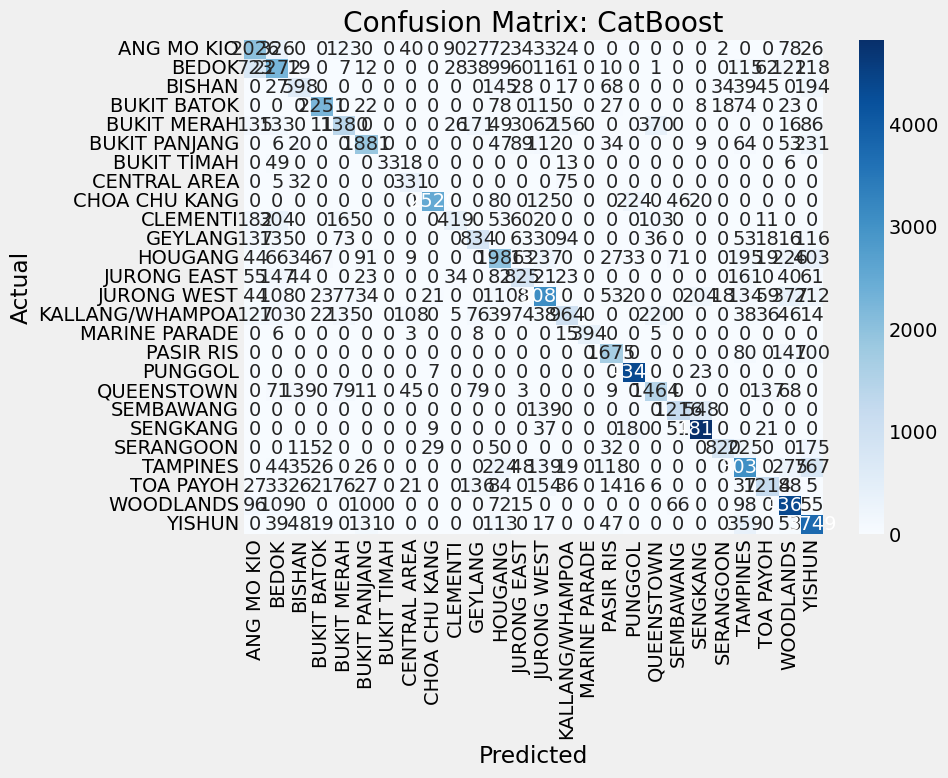

In [35]:

# Detailed Classification Report — CatBoost
if globals().get('catboost_results') is not None:
    print("Classification Report — CatBoost:")
    print("=" * 90)
    print(catboost_results['classification_report'])
    print("=" * 90)

    cm_catboost = catboost_results['confusion_matrix']
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: CatBoost')
    plt.tight_layout()
    plt.show()


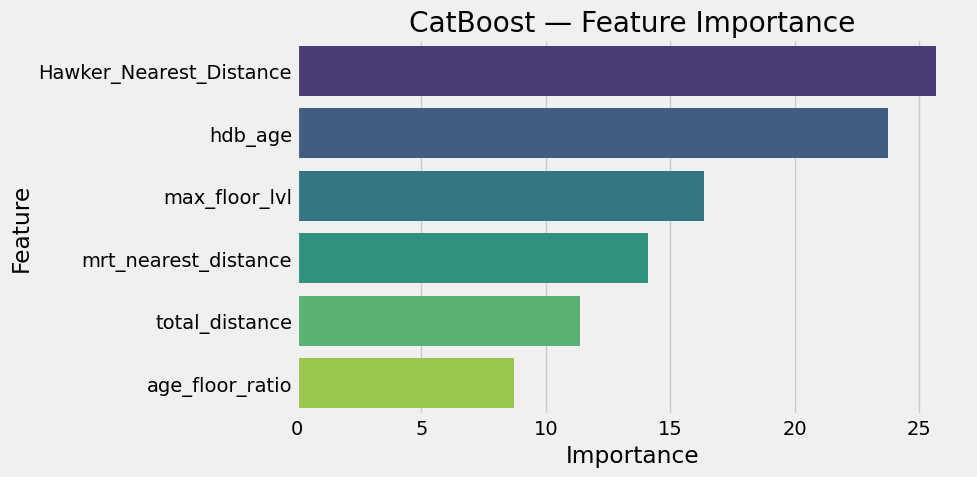

Feature Importance:
                Feature  Importance
Hawker_Nearest_Distance   25.681898
                hdb_age   23.762994
          max_floor_lvl   16.343228
   mrt_nearest_distance   14.123282
         total_distance   11.358391
        age_floor_ratio    8.730207


In [36]:

# Feature importance — CatBoost
if globals().get('catboost_results') is not None:
    catboost_importance = pd.DataFrame({
        'Feature':    FEATURE_COLUMNS,
        'Importance': catboost_results['fitted_model'].feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('CatBoost — Feature Importance')
    plt.tight_layout()
    plt.show()

    print("Feature Importance:")
    print(catboost_importance.to_string(index=False))


---

## Step 13: Model Comparison Summary

Rank all trained models side-by-side on the same train/test split.


                    MODEL COMPARISON SUMMARY (5 Models)
        Model  Train Accuracy  Test Accuracy  Train Error  Test Error
Random Forest          1.0000         0.7984       0.0000      0.2016
     LightGBM          0.9998         0.7827       0.0002      0.2173
      XGBoost          0.9756         0.7729       0.0244      0.2271
    KNN (k=1)          1.0000         0.7629       0.0000      0.2371
     CatBoost          0.8100         0.7189       0.1900      0.2811

  Best Predicting Model: Random Forest


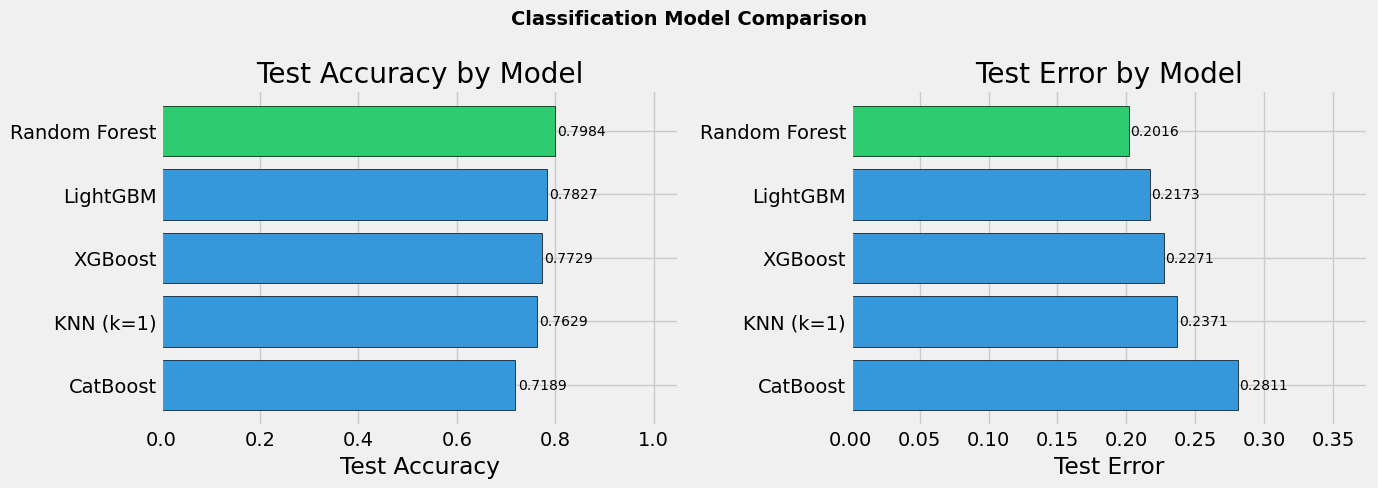

In [37]:

# Collect all trained model results for comparison.
# KNN metrics come from the variables produced in Steps 6-7.
knn_train_acc = knn_final.score(X_train_scaled, y_train)
knn_test_acc  = knn_final.score(X_test_scaled,  y_test)

all_comparison_results = [
    {
        'Model':          f'KNN (k={best_k})',
        'Train Accuracy': knn_train_acc,
        'Test Accuracy':  knn_test_acc,
        'Train Error':    1 - knn_train_acc,
        'Test Error':     1 - knn_test_acc,
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        all_comparison_results.append(res)

comparison_df = pd.DataFrame([
    {
        'Model':          r['Model'],
        'Train Accuracy': round(r['Train Accuracy'], 4),
        'Test Accuracy':  round(r['Test Accuracy'],  4),
        'Train Error':    round(r['Train Error'],     4),
        'Test Error':     round(r['Test Error'],      4),
    }
    for r in all_comparison_results
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"                    MODEL COMPARISON SUMMARY ({len(comparison_df)} Models)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 90)
print(f"  Best Predicting Model: {comparison_df.loc[0, 'Model']}")
print("=" * 90)

# Bar chart
colors = ['#2ecc71' if m == comparison_df.loc[0, 'Model'] else '#3498db'
          for m in comparison_df['Model']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison_df['Model'][::-1], comparison_df['Test Accuracy'][::-1],
             color=colors[::-1], edgecolor='black')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlim(0, 1.05)
for i, acc in enumerate(comparison_df['Test Accuracy'][::-1]):
    axes[0].text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10)

axes[1].barh(comparison_df['Model'][::-1], comparison_df['Test Error'][::-1],
             color=colors[::-1], edgecolor='black')
axes[1].set_xlabel('Test Error')
axes[1].set_title('Test Error by Model')
axes[1].set_xlim(0, comparison_df['Test Error'].max() * 1.3 + 0.01)
for i, err in enumerate(comparison_df['Test Error'][::-1]):
    axes[1].text(err + 0.001, i, f'{err:.4f}', va='center', fontsize=10)

plt.suptitle('Classification Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Step 14: Confusion Matrix Gallery

Visualise class-level prediction behaviour for every model on the same test set.  
Each cell shows how many samples of each actual town were predicted as each other town.


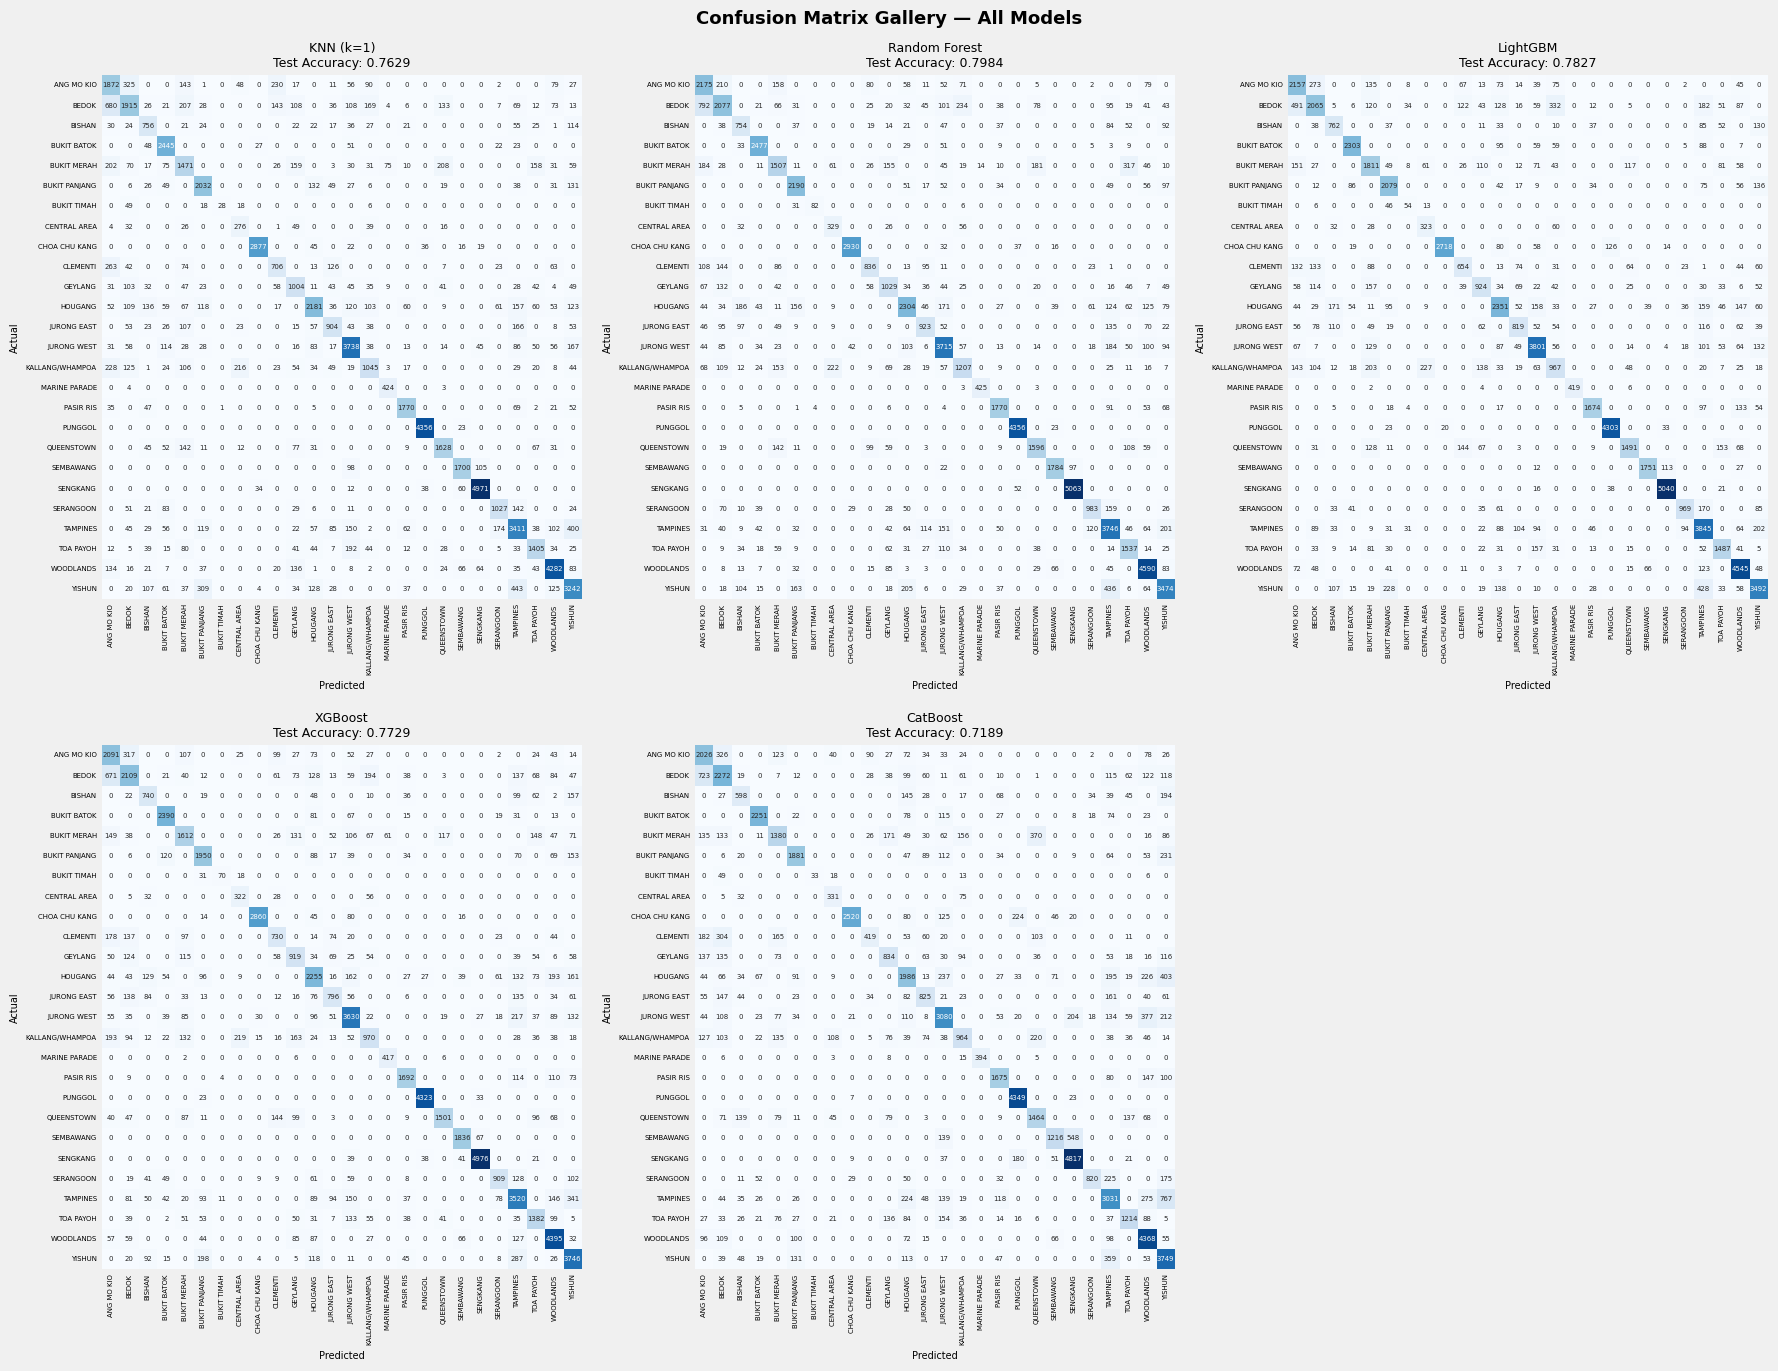

In [38]:

# Side-by-side confusion matrix gallery for all available models.
# Patch in KNN from the variables produced in Steps 6-7.
gallery_results = [
    {
        'Model':            f'KNN (k={best_k})',
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    },
    rf_results,
]

for res in [
    globals().get('lgbm_results'),
    globals().get('xgb_results'),
    globals().get('catboost_results'),
]:
    if res is not None:
        gallery_results.append(res)

n_models = len(gallery_results)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, res in enumerate(gallery_results):
    ax   = axes_flat[idx]
    cm_i = res['confusion_matrix']
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={'size': 5})
    acc_i = cm_i.diagonal().sum() / cm_i.sum()
    ax.set_title(f"{res['Model']}\nTest Accuracy: {acc_i:.4f}", fontsize=9)
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('Actual',    fontsize=7)
    ax.tick_params(axis='both', labelsize=5)

for j in range(len(gallery_results), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Confusion Matrix Gallery — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Summary

| Step | Model | Type | Notes |
|------|-------|------|-------|
| Step 6–7 | KNN | Distance-based | Tuned via K search; requires feature scaling via Pipeline |
| Step 9   | Random Forest | Ensemble | 300 trees; balanced class weights; scale-invariant |
| Step 10  | LightGBM | Gradient Boosting | Fast leaf-wise growth; scale-invariant |
| Step 11  | XGBoost | Gradient Boosting | Level-wise with regularisation; scale-invariant |
| Step 12  | CatBoost | Gradient Boosting | Handles class imbalance; scale-invariant |
| Step 13  | Comparison | — | All models ranked on the same train/test split |
| Step 14  | Gallery | — | Confusion matrix per model for visual error analysis |

**How to reuse this notebook on a new dataset:**
1. Update `TARGET_COLUMN` and `DATA_PATH` in Steps 1–2
2. Adjust `FEATURE_COLUMNS` in Step 5b (and feature engineering in Step 3.5)
3. Re-run all cells — Steps 6–14 train and compare all models automatically


In [39]:
# ============================================================
# Export best model artefacts for Flask app
# ============================================================
import joblib, json, os

os.makedirs('../app/models', exist_ok=True)

# 1. Best model (Random Forest — test accuracy 76.8%)
joblib.dump(rf_model, '../app/models/rf_classifier.joblib')

# 2. Fitted scaler (must be the one fit on X_train — same object used during training)
joblib.dump(scaler, '../app/models/scaler_classifier.joblib')

# 3. Class labels: sorted list so index matches TARGET_MAPPING encoding
town_classes = sorted(df['town'].unique().tolist())
with open('../app/models/town_classes.json', 'w') as f:
    json.dump(town_classes, f)

print("Saved artefacts to app/models/:")
print("  rf_classifier.joblib")
print("  scaler_classifier.joblib")
print("  town_classes.json")

Saved artefacts to app/models/:
  rf_classifier.joblib
  scaler_classifier.joblib
  town_classes.json
